<a href="https://colab.research.google.com/github/Hambeurger/Deep-Learning-Project-1/blob/main/Deep_Learning_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all the libraries.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import LearningRateScheduler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle as pk
import urllib.request
import zipfile

Download and extract data.

In [2]:
import urllib.request
import zipfile
import pickle as pk

# URL of the ZIP data on GitHub
zip_url = "https://github.com/Hambeurger/Deep-Learning-Project-1/raw/main/input_data.zip"

# Download the ZIP file
zip_path, _ = urllib.request.urlretrieve(zip_url)

# Unzip the file
target_folder = "temp"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_folder)

# Path to the extracted data file
data_path = f"{target_folder}/input_data.pkl"

# Load the data
with open(data_path, 'rb') as f:
    data = pk.load(f)

imgs = data['imgs']
masks = data['masks']

print(f"Images shape: {imgs.shape}")
print(f"Masks shape: {masks.shape}")


Images shape: (1305, 256, 256, 3)
Masks shape: (1305, 256, 256, 1)


Input Preprocessing:


*   Normalize the image data to have values between 0 and 1.
*   Split the data into training, validation and test sets.
*   Perform data augumentation.










In [3]:
# Take a small subset of the data for training and validation
subset_size = 100  # Adjust the subset size as needed

X_train, X_temp, y_train, y_temp = train_test_split(imgs[:subset_size], masks[:subset_size], test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Reduce image size to decrease memory usage
image_size = (128, 128)  # Adjust the size as needed

X_train_resized = np.array([tf.image.resize(img, image_size).numpy() for img in X_train])
X_val_resized = np.array([tf.image.resize(img, image_size).numpy() for img in X_val])
X_test_resized = np.array([tf.image.resize(img, image_size).numpy() for img in X_test])

# Resize target masks to match the new image size
y_train_resized = np.array([tf.image.resize(tf.image.convert_image_dtype(mask, dtype=tf.uint8), image_size, method='nearest').numpy() for mask in y_train])
y_val_resized = np.array([tf.image.resize(tf.image.convert_image_dtype(mask, dtype=tf.uint8), image_size, method='nearest').numpy() for mask in y_val])
y_test_resized = np.array([tf.image.resize(tf.image.convert_image_dtype(mask, dtype=tf.uint8), image_size, method='nearest').numpy() for mask in y_test])

# Ensure masks are integers for SparseCategoricalCrossentropy
y_train_resized = y_train_resized.astype(np.uint8)
y_val_resized = y_val_resized.astype(np.uint8)
y_test_resized = y_test_resized.astype(np.uint8)

data_gen_args = dict(rotation_range=5,  # Reduced rotation range
                     width_shift_range=0.05,  # Reduced shift range
                     height_shift_range=0.05,  # Reduced shift range
                     shear_range=0.05,  # Reduced shear range
                     zoom_range=0.05,  # Reduced zoom range
                     horizontal_flip=True,
                     fill_mode='nearest')

image_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**data_gen_args)
mask_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**data_gen_args)

Model Architecture: U-Net

*   ReLU activation functions for the hidden layers.
*   Softmax for the output.



In [4]:
# Define the U-Net model with reduced input size
def unet_model(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Contracting path
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)

    # Expansive path
    up6 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(conv5)
    up6 = layers.concatenate([up6, conv4], axis=3)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(up6)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)

    up7 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv6)
    up7 = layers.concatenate([up7, conv3], axis=3)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(up7)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up8 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv7)
    up8 = layers.concatenate([up8, conv2], axis=3)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(up8)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up9 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv8)
    up9 = layers.concatenate([up9, conv1], axis=3)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(up9)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)

    conv10 = layers.Conv2D(6, 1, activation='softmax')(conv9)

    model = models.Model(inputs=[inputs], outputs=[conv10])

    return model

Model Configuration:
*   Use Adam optimizer with a learning rate scheduler to adapt the learning rate during training.
*   Use Sparse Categorical Crossentropy as loss function.

In [5]:
model = unet_model()
model.compile(optimizer=optimizers.Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Display model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 16, 16, 512)    │      2,097,664 │ conv2d_9[0][0]         │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 16, 16, 1024)   │              0 │ conv2d_transpose[0][0… │
│                      

 Total params: 31,032,070 (118.38 MB)

 Trainable params: 31,032,070 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

Training the model.

In [6]:
# Training with data augmentation (reduced batch size)
train_generator = image_datagen.flow(X_train_resized, y_train_resized, batch_size=16, seed=42)
val_generator = image_datagen.flow(X_val_resized, y_val_resized, batch_size=16, seed=42)

# Learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 1:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

callback = LearningRateScheduler(scheduler)

# Train the model with fewer epochs
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=1,  # Reduced number of epochs
                    callbacks=[callback])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 165s 29s/step - accuracy: 0.2922 - loss: 17.6028 - val_accuracy: 0.1516 - val_loss: 5.0761 - learning_rate: 0.0010


Model Evaluation: using accuracy and Intersection-over-Union (IoU) metrics on the test set.

In [7]:
# Test data generator
test_generator = image_datagen.flow(X_test_resized, y_test_resized, batch_size=32, seed=42)
evaluation = model.evaluate(test_generator)

print(f"Test Loss: {evaluation[0]}")
print(f"Test Accuracy: {evaluation[1]}")

# Save the model
#model.save('unet_model.h5')
model.save('my_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.2675 - loss: 4.3298
Test Loss: 4.329782962799072
Test Accuracy: 0.2674926817417145


Plot training history.

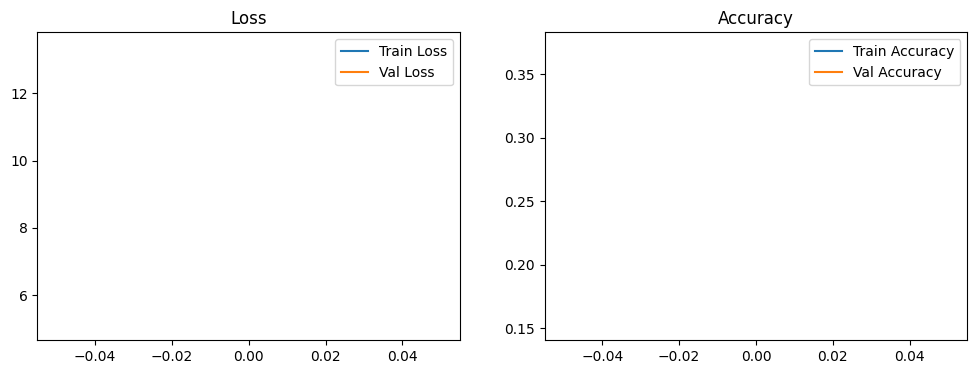

In [8]:
# Plot training & validation loss values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()